# Agentic AI in a Nutshell
**Hands-on walkthrough · Accenture Internal Knowledge Sharing · May 2026**

---

This notebook walks through every layer of an AI agent — from a bare LLM call all the way to a stateful agent that remembers who you are across conversations.

| Step | What happens |
|------|--------------|
| 1 | Plain LLM call — text in, text out |
| 2 | Define tools the LLM can use |
| 3 | Bind tools to the LLM and watch it decide |
| 4 | Full agent workflow with LangGraph |
| 5 | Human-in-the-Loop approval |
| 6 | Memory — **without** vs **with** persistence |
| Bonus | Full agent (tools + memory) |

> **Model:** `gemini-2.5-flash` · **Search:** Tavily · **Orchestration:** LangGraph

## Setup — load API keys

> **Kernel:** Select **"LangGraph Tutorial (.venv)"** in Jupyter before running.  
> All packages are already installed in `.venv/`. See README for setup steps.

In [1]:
from dotenv import load_dotenv
import os

load_dotenv()  # reads .env → GEMINI_API_KEY, TAVILY_API_KEY, LANGSMITH_*

for key in ["GEMINI_API_KEY", "TAVILY_API_KEY", "LANGSMITH_API_KEY"]:
    val = os.getenv(key, "NOT SET")
    print(f"{key}: {val[:8]}..." if val != "NOT SET" else f"{key}: NOT SET")

GEMINI_API_KEY: AIzaSyAE...
TAVILY_API_KEY: tvly-dev...
LANGSMITH_API_KEY: lsv2_pt_...


---
## Step 1 — Plain LLM Call

**Concept:** An LLM is just a function: text in → text out.  
No tools, no memory, no loop — a single round-trip.

```
You ──► LLM ──► Answer
```

In [2]:
from langchain_google_genai import ChatGoogleGenerativeAI

# Instantiate Gemini 2.5 Flash
# temperature=0 → deterministic, consistent answers (good for demos)
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0)

# .invoke() sends one message and returns one AIMessage — simplest possible call
response = llm.invoke("What is an AI agent, in one sentence?")
response.content

'An AI agent is a computational entity that perceives its environment and acts autonomously and intelligently to achieve specific goals.'

In [4]:
from langchain_core.messages import HumanMessage, SystemMessage

# We can also pass a full conversation history as a list of messages
messages = [
    # SystemMessage sets the assistant's persona / context
    SystemMessage(content="You are a helpful assistant who explains things simply."),
    HumanMessage(content="What is the difference between a chatbot and an agent?"),
]

response = llm.invoke(messages)
response

AIMessage(content='Imagine you have two helpers:\n\n1.  **A Chatbot:**\n    *   **What it is:** Think of it like a very helpful script-reader.\n    *   **What it does:** It\'s designed to chat with you, answer common questions, and follow specific rules or scripts. It\'s good at giving you information it has been programmed with.\n    *   **How it works:** It looks for keywords in your questions and gives you a pre-written answer. It doesn\'t really "understand" what you\'re saying, it just matches patterns.\n    *   **Limitations:** If you ask something it hasn\'t been taught, it gets confused or says "I don\'t understand." It can\'t make decisions or do complex tasks outside its script.\n    *   **Example:** A bot on a website that tells you the FAQ, or helps you order a pizza by asking "Do you want pepperoni or cheese?"\n\n2.  **An Agent (or AI Agent):**\n    *   **What it is:** This helper is much smarter and more independent.\n    *   **What it does:** It doesn\'t just answer ques

---
## Step 2 — Define Tools

**Concept:** Tools are Python functions the agent can call.  
The LLM never runs them directly — it *decides* to call one, and the framework executes it.

```
LLM decides ──► Agent executes tool ──► Result fed back to LLM
```

We'll define two tools:
- **`calculator`** — safe math evaluation (no internet needed)
- **`web_search`** — live Tavily web search

In [43]:
from langchain_core.tools import tool

# @tool turns a plain Python function into a LangChain tool.
# The docstring is what the LLM reads to decide WHEN and HOW to use this tool.

@tool
def calculator(expression: str) -> str:
    """Evaluate a mathematical expression and return the numeric result.
    Use this for complex calculations involving +, -, *, /, **, %.
    Example input: '(12 + 8) * 3 / 2'
    """
    try:
        result = eval(expression, {"__builtins__": {}}, {})
        return str(result)
    except Exception as e:
        return f"Error: {e}"


@tool
def multiply(a: int, b: int) -> int:
    """Multiply two integers and return the result.
    Use this when the user asks to multiply two specific numbers.
    Example: multiply(5, 3) returns 15
    """
    return a * b


# Quick tests — tools are just Python functions, we can call them directly
print("calculator('(12 + 8) * 3 / 2') =", calculator.invoke("(12 + 8) * 3 / 2"))
print("calculator('2 ** 10')          =", calculator.invoke("2 ** 10"))
print("multiply(5, 3)                 =", multiply.invoke({"a": 5, "b": 3}))
print("multiply(3, 9)                 =", multiply.invoke({"a": 3, "b": 9}))

calculator('(12 + 8) * 3 / 2') = 30.0
calculator('2 ** 10')          = 1024
multiply(5, 3)                 = 15
multiply(3, 9)                 = 27


In [44]:
from langchain_community.tools.tavily_search import TavilySearchResults

# Pre-built Tavily tool — queries the search API and returns snippets
# max_results=3 keeps latency and cost low
web_search = TavilySearchResults(max_results=3)

results = web_search.invoke("What is LangGraph used for?")
for r in results:
    print(r["url"])
    print(r["content"][:200])
    print("---")

https://www.scalablepath.com/ai/langgraph
That’s where LangGraph comes in. LangGraph is a framework for building stateful, multi-agent applications powered by large language models. It helps developers move beyond the limitations of single-tu
---
https://www.ibm.com/think/topics/langgraph
LangGraph is also built on several key technologies, including LangChain, a Python framework for building AI applications. LangChain includes a library for building and managing LLMs. LangGraph also u
---
https://medium.com/@ashutoshsharmaengg/getting-started-with-langgraph-a-beginners-guide-to-building-intelligent-workflows-67eeee0899d0
# # ... print outputs ...

Image 3

LLM Token Counter Workflow

This simple setup demonstrates how LangGraph connects functions into a flow.

### Key Takeaways from this Example:

1. Graph vs. StateGr
---


In [45]:
import requests

@tool
def get_weather(city: str) -> str:
    """Get the current weather for a city.
    Use this for ANY weather-related question — do NOT use web_search for weather.
    Example: get_weather("Jakarta") or get_weather("London")
    """
    try:
        geo = requests.get(
            "https://geocoding-api.open-meteo.com/v1/search",
            params={"name": city, "count": 1, "language": "en", "format": "json"},
            timeout=10,
        ).json()
        results = geo.get("results", [])
        if not results:
            return f"City '{city}' not found."
        lat, lon = results[0]["latitude"], results[0]["longitude"]
        name, country = results[0]["name"], results[0].get("country", "")

        wx = requests.get(
            "https://api.open-meteo.com/v1/forecast",
            params={
                "latitude": lat, "longitude": lon,
                "current": "temperature_2m,weathercode,windspeed_10m,relativehumidity_2m",
                "temperature_unit": "celsius", "timezone": "auto",
            },
            timeout=10,
        ).json()
        curr = wx["current"]
        wmo = {
            0: "Clear sky", 1: "Mainly clear", 2: "Partly cloudy", 3: "Overcast",
            45: "Foggy", 51: "Light drizzle", 61: "Slight rain", 63: "Moderate rain",
            80: "Slight showers", 81: "Moderate showers", 95: "Thunderstorm",
        }
        condition = wmo.get(curr["weathercode"], f"Code {curr['weathercode']}")
        return (
            f"Weather in {name}, {country}: {condition}, "
            f"{curr['temperature_2m']}\u00b0C, "
            f"Humidity: {curr.get('relativehumidity_2m', 'N/A')}%, "
            f"Wind: {curr['windspeed_10m']} km/h"
        )
    except Exception as e:
        return f"Error fetching weather: {e}"

# Quick test — should return real current weather
print(get_weather.invoke("Jakarta"))

Weather in Jakarta, Indonesia: Slight showers, 24.6°C, Humidity: 96%, Wind: 3.2 km/h


In [46]:
# Bundle all tools — this list is what we hand to the LLM
#   multiply    → simple integer multiplication (easy to trace)
#   calculator  → full expression evaluator for complex math
#   get_weather → dedicated weather API (Open-Meteo, free, no API key)
#   web_search  → Tavily for general knowledge / factual lookups
tools = [multiply, calculator, get_weather, web_search]

for t in tools:
    print(f"Tool : {t.name}")
    print(f"Desc : {t.description[:120]}...\n")

Tool : multiply
Desc : Multiply two integers and return the result.
    Use this when the user asks to multiply two specific numbers.
    Examp...

Tool : calculator
Desc : Evaluate a mathematical expression and return the numeric result.
    Use this for complex calculations involving +, -, ...

Tool : get_weather
Desc : Get the current weather for a city.
    Use this for ANY weather-related question — do NOT use web_search for weather.
 ...

Tool : tavily_search_results_json
Desc : A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need to answer questions...



---
## Step 3 — LLM with Tool Calling

**Concept:** `bind_tools()` attaches tool schemas to every request.  
Now the LLM can reply with plain text **or** a tool call request.

```
User asks ──► LLM sees tool schemas
                 │
                 ├── needs tool? ──► returns tool_call
                 └── no tool? ───► returns text
```

In [47]:
# bind_tools() sends tool schemas alongside every message so the LLM knows they exist
llm_with_tools = llm.bind_tools(tools)

response = llm_with_tools.invoke("What is 5 multiplied by 3?")

# ── IMPORTANT — understanding the two-phase tool call ─────────────────────
# When the LLM decides to use a tool it does NOT return a text answer.
# Instead it returns a *request* to run a tool:
#
#   response.content    → empty ("")  — the LLM hasn't answered yet
#   response.tool_calls → [{"name": "multiply", "args": {"a": 5, "b": 3}, ...}]
#
# The actual result only exists AFTER we execute the tool and send it back.
# The next cell shows how to complete that loop manually.
print("Tool calls :", response.tool_calls)
print("Text content:", repr(response.content))
print()
print("👆  content is empty — the LLM is waiting for the tool result before answering.")

Tool calls : [{'name': 'multiply', 'args': {'b': 3, 'a': 5}, 'id': 'dc66c588-b3cf-4d8f-b2a5-80245fee9dcf', 'type': 'tool_call'}]
Text content: ''

👆  content is empty — the LLM is waiting for the tool result before answering.


In [49]:
without_tool = llm.invoke("What is 5 multiplied by 3?")
without_tool.content

'5 multiplied by 3 is **15**.'

In [50]:
from langchain_core.messages import ToolMessage

tool_map = {t.name: t for t in tools}

# Conversation so far: user question + LLM's tool-call response (content still empty)
messages = [
    HumanMessage(content="What is 5 multiplied by 3?"),
    response,
]

# Execute each tool the LLM requested and wrap the result in a ToolMessage
for tc in response.tool_calls:
    print(f"  → running '{tc['name']}' with args {tc['args']}")
    result = tool_map[tc["name"]].invoke(tc["args"])
    print(f"  ← result : {result}")
    # ToolMessage links the result back to the specific call via tool_call_id
    messages.append(ToolMessage(content=str(result), tool_call_id=tc["id"]))

# Send the full conversation back — LLM now has the tool result and can answer
final = llm_with_tools.invoke(messages)
print("\nFinal answer:", final.content)
print("\n👆  Now content is populated — the LLM used the tool result to answer.")

  → running 'multiply' with args {'b': 3, 'a': 5}
  ← result : 15

Final answer: 5 multiplied by 3 is 15.

👆  Now content is populated — the LLM used the tool result to answer.


---
## Step 4 — Agent Workflow with LangGraph

**Concept:** LangGraph turns the message loop into a graph of nodes and edges:

```
START ──► [agent] ──► tool needed? ──yes──► [tools] ──► back to agent
                   └──no──► END
```

Three building blocks:
- **State** — shared notebook (messages list) that flows through the graph
- **Nodes** — Python functions that read/update the state
- **Edges** — arrows that decide what node runs next

The loop runs automatically until the LLM stops requesting tools.

In [51]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition

# --- State ---
# add_messages is a reducer: new messages are APPENDED, not replaced
class AgentState(TypedDict):
    messages: Annotated[list, add_messages]


# --- Agent node ---
# Sends current messages to the LLM and appends the response
def agent_node(state: AgentState):
    response = llm_with_tools.invoke(state["messages"])
    return {"messages": [response]}


# --- Build the graph ---
builder = StateGraph(AgentState)

builder.add_node("agent", agent_node)       # LLM reasoning step
builder.add_node("tools", ToolNode(tools))  # executes whatever tool the LLM requested

builder.add_edge(START, "agent")            # always start with the agent

# tools_condition: if last message has tool_calls → "tools", else → END
builder.add_conditional_edges("agent", tools_condition)

# After tools run, go back to the agent for the next reasoning step
builder.add_edge("tools", "agent")

graph = builder.compile()
print("Graph compiled.")

Graph compiled.


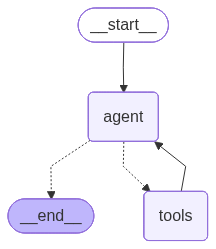

In [52]:
# ── Visualise the graph BEFORE running it ──────────────────────────────────
# This shows the full workflow as a diagram so you can see the shape first.
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # Fallback: print Mermaid source (paste at mermaid.live to view)
    print(graph.get_graph().draw_mermaid())

In [53]:
# ── Now run it ─────────────────────────────────────────────────────────────
print("Question: What is the latest version of LangGraph?\n")

# .stream() yields a state snapshot after each node so we can watch the loop
for step in graph.stream(
    {"messages": [HumanMessage(content="What is the latest version of LangGraph?")]},
    stream_mode="values",
):
    last = step["messages"][-1]
    kind = last.__class__.__name__
    if kind == "AIMessage" and last.tool_calls:
        for tc in last.tool_calls:
            print(f"[AGENT] → calling '{tc['name']}' with: {tc['args']}")
    elif kind == "ToolMessage":
        print(f"[TOOL]  ← {last.content[:200]}")
    elif kind == "AIMessage" and last.content:
        print(f"[AGENT] Final answer:\n{last.content}")

Question: What is the latest version of LangGraph?

[AGENT] → calling 'tavily_search_results_json' with: {'query': 'latest version of LangGraph'}
[TOOL]  ← [{"title": "LangGraph Enhances AI Development with Version 0.3 Release", "url": "https://www.cointrust.com/market-news/langgraph-enhances-ai-development-with-version-0-3-release", "content": "CoinTrus
[AGENT] Final answer:
[{'type': 'text', 'text': 'The latest version of LangGraph is 1.2.0.', 'extras': {'signature': 'CsYUAQw51sdZY7ageXiTcH4vIqOIvE6cHciSTQhdVQAWA4WAVFq2cvVQUDneyefBT8d4HVe+W+eZ2nnnm/0MGIb0HykEc+c9FFbsWF3PTeHF9oUnMfnph5LD7qXCIXsayCnR1M7HAVknwZt0CEK10KvDRpaz6/q8tucPtag/bUdphg06RXyp3X8U4d+cOEW8meIChz7NCsZNTwpmNX/VacbDLerxmeu6NWmkOAhOUtWKCQjBPRI0h3L7wR0NeSIadqzbauFXU2au57wYQFcAuTRk7+9OQI50m5UfFnvs8BZUgXTnqfmN1b+umPPoIdWFGU9MXibs8pNjwXU5Hv/4JNrc8ixEB9Bv+FqDyDw+G1k9FUUln25u7n7sk6ilIFWEGanAECQYzG4HYZaQkvdWYo2EK8jzac22vBGgQeLerpi3GgDlpC1VwWfU/rQohK+aU1ft4tTzr5F9HFNVRupDcvFR6kk1jvJQo+bXhWdlrf8JJeT1hjq4ENgjFNHGfQO2c+VKqVskRXOUL

In [54]:
# Ask something that uses BOTH tools in one turn
print("Question: What is 15% of 280, and who invented the calculator?\n")

for step in graph.stream(
    {"messages": [HumanMessage(content="What is 15% of 280, and who invented the calculator?")]},
    stream_mode="values",
):
    last = step["messages"][-1]
    kind = last.__class__.__name__
    if kind == "AIMessage" and last.tool_calls:
        for tc in last.tool_calls:
            print(f"[AGENT] → calling '{tc['name']}' with: {tc['args']}")
    elif kind == "ToolMessage":
        print(f"[TOOL]  ← {last.content[:200]}")
    elif kind == "AIMessage" and last.content:
        print(f"[AGENT] Final answer:\n{last.content}")

Question: What is 15% of 280, and who invented the calculator?

[AGENT] → calling 'calculator' with: {'expression': '0.15 * 280'}
[AGENT] → calling 'tavily_search_results_json' with: {'query': 'who invented the calculator'}
[TOOL]  ← [{"title": "Calculator - Wikipedia", "url": "https://en.wikipedia.org/wiki/Calculator", "content": "The Renaissance saw the invention of the mechanical calculator by Wilhelm Schickard in 1623, and lat
[AGENT] Final answer:
[{'type': 'text', 'text': '15% of 280 is 42.\n\nThe invention of the calculator has a rich history with several key figures. Blaise Pascal is widely recognized for inventing one of the first mechanical calculators, the Pascaline, in the 1640s. However, Wilhelm Schickard also invented a mechanical calculator earlier, in 1623. Later, in 1834, Luigi Torchi invented the first direct multiplication machine. The first handheld mechanical calculator was invented by Curt Herzstark in 1945.', 'extras': {'signature': 'Cv8DAQw51sdW8rygzAS1yntYEb/aF

---
## Step 5 — Human-in-the-Loop

**Concept:** Some tool calls are risky (send an email, delete a record, file a ticket).  
We want a human to review before they execute.

LangGraph supports this with `interrupt_before`: the graph **pauses** before a node,  
lets a human inspect state, then **resumes** when approved.

```
agent ──► [PAUSE — human reviews]
                │
                ├── approve ──► tools ──► agent ──► END
                └── reject  ──► END
```

Requires a **checkpointer** so state survives the pause.

In [55]:
from langgraph.checkpoint.memory import MemorySaver

hitl_checkpointer = MemorySaver()  # stores state in memory during the pause

# interrupt_before=["tools"] → pause the graph just before the tools node runs
hitl_graph = builder.compile(
    checkpointer=hitl_checkpointer,
    interrupt_before=["tools"],
)

print("Human-in-the-Loop graph compiled.")

Human-in-the-Loop graph compiled.


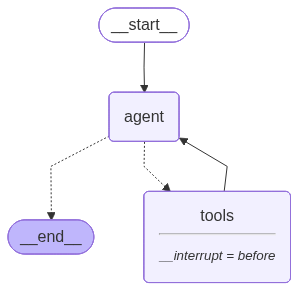

In [56]:
# ── Visualise HITL graph ───────────────────────────────────────────────────
try:
    display(Image(hitl_graph.get_graph().draw_mermaid_png()))
except Exception:
    print(hitl_graph.get_graph().draw_mermaid())

In [57]:
# Each conversation thread needs a unique ID so the checkpointer can find its state
thread_cfg = {"configurable": {"thread_id": "hitl-demo-1"}}

# Run until the graph pauses at 'tools'
print("Sending question...\n")
for step in hitl_graph.stream(
    {"messages": [HumanMessage(content="Search the web: who founded Anthropic?")]},
    config=thread_cfg,
    stream_mode="values",
):
    last = step["messages"][-1]
    if hasattr(last, "tool_calls") and last.tool_calls:
        print("[AGENT] Wants to call:")
        for tc in last.tool_calls:
            print(f"  Tool: {tc['name']}")
            print(f"  Args: {tc['args']}")

# Check where the graph is paused
paused_state = hitl_graph.get_state(thread_cfg)
print(f"\nGraph paused. Next node: {paused_state.next}")
print(">>> Human review required <<<")

Sending question...

[AGENT] Wants to call:
  Tool: tavily_search_results_json
  Args: {'query': 'who founded Anthropic'}

Graph paused. Next node: ('tools',)
>>> Human review required <<<


In [58]:
decision = input("Approve tool call? (yes/no): ").strip().lower()

if decision == "yes":
    print("\nApproved — resuming...\n")
    # Passing None as input means "continue from the pause point, no new messages"
    for step in hitl_graph.stream(None, config=thread_cfg, stream_mode="values"):
        last = step["messages"][-1]
        kind = last.__class__.__name__
        if kind == "ToolMessage":
            print(f"[TOOL]  ← {last.content[:300]}")
        elif kind == "AIMessage" and last.content:
            print(f"[AGENT] Final answer:\n{last.content}")
else:
    print("Rejected — tool call cancelled.")

Approve tool call? (yes/no):  Yes



Approved — resuming...

[TOOL]  ← [{"title": "Anthropic Business Breakdown & Founding Story | Contrary Research", "url": "https://research.contrary.com/company/anthropic", "content": "Dario Amodei left OpenAI in December 2020, and 14 other researchers, including his sister Daniela Amodei, eventually left to join Anthropic as well. T
[AGENT] Final answer:
[{'type': 'text', 'text': 'Anthropic was founded by siblings Dario Amodei and Daniela Amodei, along with Jared Kaplan, Jack Clark, Chris Olah, Ben Mann, Sam McCandlish, and Tom Brown. They were all former members of OpenAI.', 'extras': {'signature': 'CrkCAQw51sfSWabJSffr0i4tx0xCel17I4RJZO6kwMXaYnlhYGXFFhrRVZAkLhj6inC5ZMweTXt8C+wjDF4Xpxp7MtFey+nTvgOS57OhoAl03nT85/qzXsY7D6ih2W9IvttSDGiDQBrkn/LGikPi0uKTeF8nocpEleHB74J5CP4B3L02HmMWmisNPRq1j3pAl7e5N1LZstKDEvVCYKll2oKY+iuEHpmcAmc87l5NcfwL0byKbq5Afc7eSbpvop/Wbk3fWUR+K9hCqbJ02dbtzT4epgtnEuuM7x/+x5Dc5uPMFvUVWNugGiZdB6V9R0ABTD0O4ZP+hcoYt66cIGjJLtZy+qooT10WbVaOdWKfR3IO/OS19VIWDGPOCct3qM/grCL6K4o

---
## Step 6 — Memory: Without vs With Persistence

### Part A — Without memory (stateless)

**Concept:** Every call is independent. The agent has no idea what was said before.

```
Call 1: "My name is Fadly"  ──► [LLM]  ──► "Nice to meet you!"
Call 2: "What is my name?"  ──► [LLM]  ──► "I don't know" ← NO memory!
```

We'll prove this by sending two separate `.invoke()` calls with **no shared state**.

In [59]:
# ── No-memory graph — plain LLM, no checkpointer ──────────────────────────
from langgraph.graph import StateGraph, START, END


def chat_node(state: AgentState):
    return {"messages": [llm.invoke(state["messages"])]}


no_memory_builder = StateGraph(AgentState)
no_memory_builder.add_node("chat", chat_node)
no_memory_builder.add_edge(START, "chat")
no_memory_builder.add_edge("chat", END)

# Compiled WITHOUT a checkpointer — each .invoke() starts completely fresh
no_memory_graph = no_memory_builder.compile()

print("No-memory graph compiled.")

No-memory graph compiled.


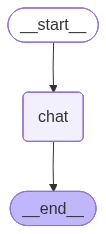

In [60]:
# ── Visualise ──────────────────────────────────────────────────────────────
try:
    display(Image(no_memory_graph.get_graph().draw_mermaid_png()))
except Exception:
    print(no_memory_graph.get_graph().draw_mermaid())

In [21]:
# ── Customise: change USER_NAME to your own name ────────────────────────
USER_NAME = "Fadly"  # ← edit this

intro_msg = f"Hi! My name is {USER_NAME}. Remember that."

result1 = no_memory_graph.invoke(
    {"messages": [HumanMessage(content=intro_msg)]}
)
print(f"[Invoke 1]  User : {intro_msg}")
print(f"[Invoke 1]  Agent: {result1['messages'][-1].content}")

[Invoke 1] Agent: Hi Fadly! It's nice to meet you. I'll remember that.


In [22]:
# ── Invoke 2: fresh call — does it remember? ───────────────────────────────
# This is a brand-new .invoke() with NO connection to the previous call.
result2 = no_memory_graph.invoke(
    {"messages": [HumanMessage(content="What is my name?")]}
)
print("[Invoke 2] Agent:", result2["messages"][-1].content)
print("\n👆 The agent has no idea — each call is isolated.")

[Invoke 2] Agent: As an AI, I don't know your name. I don't have access to personal information about you.

If you'd like me to know your name for our conversation, feel free to tell me!

👆 The agent has no idea — each call is isolated.


### Part B — With memory (persistent)

**Concept:** A **checkpointer** saves the full message history after every node.  
As long as we use the **same `thread_id`**, the agent picks up exactly where it left off.

```
Thread A, Call 1: "My name is Fadly" ──► [saved to checkpoint]
Thread A, Call 2: "What is my name?" ──► replays history ──► "Your name is Fadly!"
Thread B, Call 1: "What is my name?" ──► fresh thread ──► "I don't know"
```

In [23]:
memory_checkpointer = MemorySaver()  # in-memory store; swap for SQLite/Postgres in prod

# Same graph, same nodes — the ONLY difference is the checkpointer
memory_graph = no_memory_builder.compile(checkpointer=memory_checkpointer)

print("Memory graph compiled.")

Memory graph compiled.


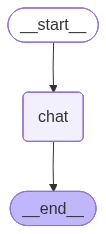

In [24]:
# ── Visualise memory graph ─────────────────────────────────────────────────
try:
    display(Image(memory_graph.get_graph().draw_mermaid_png()))
except Exception:
    print(memory_graph.get_graph().draw_mermaid())

In [25]:
# ── Customise: change these to your own details ──────────────────────────
USER_NAME      = "Fadly"      # ← edit this
USER_WORKPLACE = "Accenture"  # ← edit this

# Helper: chat with a specific thread
def chat(message: str, thread_id: str) -> str:
    config = {"configurable": {"thread_id": thread_id}}
    result = memory_graph.invoke(
        {"messages": [HumanMessage(content=message)]}, config=config
    )
    return result["messages"][-1].content

print("Helper ready. USER_NAME =", USER_NAME, "| USER_WORKPLACE =", USER_WORKPLACE)

[Thread A | Turn 1]
User: Hi! My name is Fadly. I work at Accenture.
Agent: Hello Fadly! Nice to meet you. Accenture is a fantastic company.

How can I help you today?


In [ ]:
# ── Thread A | Turn 1 — the user introduces themselves ───────────────────
intro = f"Hi! My name is {USER_NAME}. I work at {USER_WORKPLACE}."

print("[Thread A | Turn 1]")
print("User :", intro)
print("Agent:", chat(intro, "thread-A"))

In [26]:
# Thread A — same thread, second turn — does it remember?
print("[Thread A | Turn 2]")
print("User: What is my name and where do I work?")
print("Agent:", chat("What is my name and where do I work?", "thread-A"))

[Thread A | Turn 2]
User: What is my name and where do I work?
Agent: Your name is **Fadly** and you work at **Accenture**.


In [27]:
# Thread B — different thread_id → completely fresh state
print("[Thread B | Turn 1 — brand-new thread]")
print("User: What is my name and where do I work?")
print("Agent:", chat("What is my name and where do I work?", "thread-B"))
print("\n👆 Thread B has no history — it can't know.")

[Thread B | Turn 1 — brand-new thread]
User: What is my name and where do I work?
Agent: As an AI, I don't have access to personal information about you, including your name or where you work. I don't know who you are in the real world.

👆 Thread B has no history — it can't know.


In [28]:
# Inspect what is stored in Thread A's checkpoint
state_a = memory_graph.get_state({"configurable": {"thread_id": "thread-A"}})
print(f"Messages stored in Thread A: {len(state_a.values['messages'])}\n")
for msg in state_a.values["messages"]:
    role = msg.__class__.__name__.replace("Message", "")
    print(f"[{role}] {msg.content[:200]}")

Messages stored in Thread A: 4

[Human] Hi! My name is Fadly. I work at Accenture.
[AI] Hello Fadly! Nice to meet you. Accenture is a fantastic company.

How can I help you today?
[Human] What is my name and where do I work?
[AI] Your name is **Fadly** and you work at **Accenture**.


---
## Bonus — Full Agent: Tools + Persistent Memory

Combining everything into one graph:
- Web search + calculator tools
- Persistent memory across turns

The agent can search the web, do math, and remember who you are — all in one thread.

In [29]:
full_checkpointer = MemorySaver()

# Reuse the agent builder from Step 4 — just add a checkpointer
full_agent = builder.compile(checkpointer=full_checkpointer)

print("Full agent compiled.")

Full agent compiled.


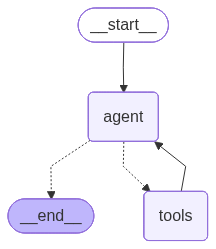

In [30]:
# ── Visualise full agent graph ─────────────────────────────────────────────
try:
    display(Image(full_agent.get_graph().draw_mermaid_png()))
except Exception:
    print(full_agent.get_graph().draw_mermaid())

In [31]:
# ── Customise: change USER_NAME to your own details ──────────────────────
USER_NAME     = "Fadly"    # ← edit this
FAVOURITE_NUM = 42         # ← edit this

THREAD = "full-demo-1"


def run(message: str):
    config = {"configurable": {"thread_id": THREAD}}
    print(f"User: {message}")
    for step in full_agent.stream(
        {"messages": [HumanMessage(content=message)]},
        config=config,
        stream_mode="values",
    ):
        last = step["messages"][-1]
        kind = last.__class__.__name__
        if kind == "AIMessage" and last.tool_calls:
            for tc in last.tool_calls:
                print(f"  [tool call] {tc['name']}({tc['args']})")
        elif kind == "ToolMessage":
            print(f"  [tool result] {last.content[:150]}")
        elif kind == "AIMessage" and last.content:
            print(f"Agent: {last.content}\n")


# Turn 1 — introduce ourselves
print("--- Turn 1 ---")
run(f"Hello! I'm {USER_NAME}, a software engineer. My favourite number is {FAVOURITE_NUM}.")

--- Turn 1 ---
User: Hello! I'm Fadly, a software engineer. My favourite number is 42.
Agent: [{'type': 'text', 'text': "Hello Fadly, it's nice to meet you! 42 is a great number. Is there anything I can help you with today, perhaps a calculation or some information?", 'extras': {'signature': 'CtABAQw51scVCOhjbjbWvlyvAsReH44Yv6m2NB9RVcpjl7R2fDISFsxfgHZ58ehNoN+/rYYIShOcjzsSC1IIN4GD3gUsCq69GvSO4NUBVHcAaEcroYAOltt/plUlr5kngdDWWAvrB1NqVwJQN5CEMCbSXAL4uLwaFzO+tclUhEFz7Nu8NZ6KLxXmOv3CTFqi0lQV8uJn1ep6l+5UBfiSd4WYyv4+Joev/7EAirbBFcd7+slrUtgE0+VB1ja1CyeeNpfL4if6SJoo2jgRTjqP73dHMQ=='}}]



In [32]:
# Turn 2 — use search tool
print("--- Turn 2 ---")
run("What is the current weather in Jakarta?")

--- Turn 2 ---
User: What is the current weather in Jakarta?
  [tool call] tavily_search_results_json({'query': 'current weather in Jakarta'})
  [tool result] [{"title": "Jakarta weather in May 2026 | Jakarta 14 day weather", "url": "https://www.weather25.com/asia/indonesia/jakarta-raya/jakarta?page=month&mo
Agent: [{'type': 'text', 'text': "I couldn't find the *current* weather for Jakarta in the search results, only forecasts for May 2026. It seems my search was not precise enough. Let me try again with a more specific query.", 'extras': {'signature': 'Cv8BAQw51se8TsY+ZKWND2T6buacxDhlAb0JH/I7K3SS7OAjWSVLeu1OkrfAlhcfbYc8kZ8H51Iclo0lJzu1X4YR0i3oFy+rmyUfaZKMxXmZXhGCI90xTTGqzJvB37JA+SHpU3mMIclqWd+jD8Sw+LwvNmF8iDf8AIGpMLjrWveOR6HVoetl6lX4qrskPoFCke8ULzzO8GiyMMnb0FYvfRUndADvw7pDFqLptHykdEnS7OIuiL/FT9dL1rlZThdsFojeXEam5yTt7X7nRUlxRXc18bAGAwWvlTuYTiHka0ZFXqAdgEWU1FFjdOd2D+KdMMGG38TDc80rHPM/EPibNDoV'}}]



In [33]:
# Turn 3 — memory check: does it still know who we are?
print("--- Turn 3 ---")
run("What is my name and what is my favourite number? You already know, don't search.")

--- Turn 3 ---
User: What is my name and what is my favourite number? You already know, don't search.
Agent: [{'type': 'text', 'text': 'Your name is Fadly and your favorite number is 42.', 'extras': {'signature': 'CvMBAQw51scFSZxLFPQQxfOmajCXtcPeVyunf4gI+H9s9JsBY0F5dRQYzH6PWwNCezi4jhdv6q6083JdIe3fKLE6JElGD6B40oJwm7ANkGrVBhRFNjbKFCqf2ZUnRL8rIJCOpaaVd1m0vLU/Vp3N1OuvHEFUuGv/TAUh1H7maUO7jvHT4+lPtWux+0XGIrnMun4saehz8O4CZBcxOcZfaTjRPQetpmRUUK4JqssJedG83M8gbTC3LCe7VPjO37JNuofkUXnOMJACJNQyPbjXUd7eRPXje0uhJCCLWMJBtqvrFqrABdHRqmB9m0+dMoIyPGS0jcLS'}}]



---
## Summary

| Step | What you built | Key API |
|------|----------------|---------|
| 1 | Plain LLM call | `llm.invoke(messages)` |
| 2 | Tools | `@tool`, `TavilySearchResults` |
| 3 | Tool calling | `llm.bind_tools()`, `tool_calls` |
| 4 | LangGraph workflow | `StateGraph`, `ToolNode`, `tools_condition` |
| 5 | Human-in-the-Loop | `interrupt_before`, `get_state`, resume with `None` |
| 6A | No memory | stateless `.invoke()` — agent forgets |
| 6B | Persistent memory | `MemorySaver` + `thread_id` — agent remembers |
| Bonus | Full agent | tools + memory combined |

### Resources

- [LangGraph docs](https://langchain-ai.github.io/langgraph)
- [Building effective agents — Anthropic](https://www.anthropic.com/engineering/building-effective-agents)
- [AI Engineer Roadmap](https://roadmap.sh/ai-engineer)
- LangSmith tracing is already enabled via `LANGSMITH_TRACING=true` in your `.env`

> _Agents act, chatbots answer. The shift is loops + tools — not bigger models._